# 01 — Exploratory Data Analysis
Before running any causal methods, we explore the simulated dataset to understand:
- The shape and structure of the data
- Covariate distributions by treatment group
- The naive (biased) ATE and why it's misleading
- Pre/post outcome trends
- Propensity score overlap

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.simulate_data import SimConfig, simulate_discount_data, to_user_level_post
from src.utils import diff_in_means_ate
from src.psm import estimate_propensity

cfg = SimConfig(n_users=8000, seed=42)
df, meta = simulate_discount_data(cfg)
df_post = to_user_level_post(df)

print(f"Panel shape: {df.shape}")
print(f"Post-period shape: {df_post.shape}")
print(f"True ATE (post): {meta['ate_true_post']:.4f}")
print(f"Tau (log-odds): {meta['tau_log_odds']:.4f}")

Panel shape: (16000, 11)
Post-period shape: (8000, 11)
True ATE (post): 0.0807
Tau (log-odds): 0.5500


## 1. Dataset Overview

In [2]:
print("--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Summary Stats (post period) ---")
df_post.describe().round(3)

--- Data Types ---
post                 int64
Y                    int64
user_id              int64
T                    int64
age                float64
income             float64
prior_purchases      int64
sessions             int64
is_mobile            int64
p_y0_post          float64
p_y1_post          float64
dtype: object

--- Missing Values ---
post               0
Y                  0
user_id            0
T                  0
age                0
income             0
prior_purchases    0
sessions           0
is_mobile          0
p_y0_post          0
p_y1_post          0
dtype: int64

--- Summary Stats (post period) ---


,post,Y,user_id,T,age,income,prior_purchases,sessions,is_mobile,p_y0_post,p_y1_post
count,8000.0,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000
mean,1.0,0.248,3999.500,0.492,32.343,35223.744,1.206,5.992,0.554,0.208,0.289
std,0.0,0.432,2309.545,0.500,9.364,12308.790,1.100,2.445,0.497,0.182,0.210
min,1.0,0.000,0.000,0.000,18.000,20000.000,0.000,0.000,0.000,0.011,0.018
25%,1.0,0.000,1999.750,0.000,25.223,26087.761,0.000,4.000,0.000,0.075,0.123
50%,1.0,0.000,3999.500,0.000,31.932,32966.887,1.000,6.000,1.000,0.145,0.228
75%,1.0,0.000,5999.250,1.000,38.726,41593.698,2.000,8.000,1.000,0.279,0.402
max,1.0,1.000,7999.000,1.000,70.000,157578.573,8.000,16.000,1.000,0.991,0.995


## 2. Treatment Group Sizes

T
Control    4061
Treated    3939
Name: count, dtype: int64

Treatment rate: 49.24%


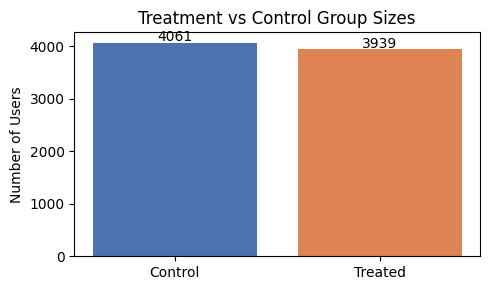

In [3]:
counts = df_post["T"].value_counts().rename({0: "Control", 1: "Treated"})
print(counts)
print(f"\nTreatment rate: {df_post['T'].mean():.2%}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Control", "Treated"], counts.values, color=["#4C72B0", "#DD8452"])
ax.set_title("Treatment vs Control Group Sizes")
ax.set_ylabel("Number of Users")
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 3. Covariate Distributions by Treatment Group
Because treatment assignment is **confounded**, we expect treated and control users to look different on covariates. This is what makes naive ATE estimation biased.

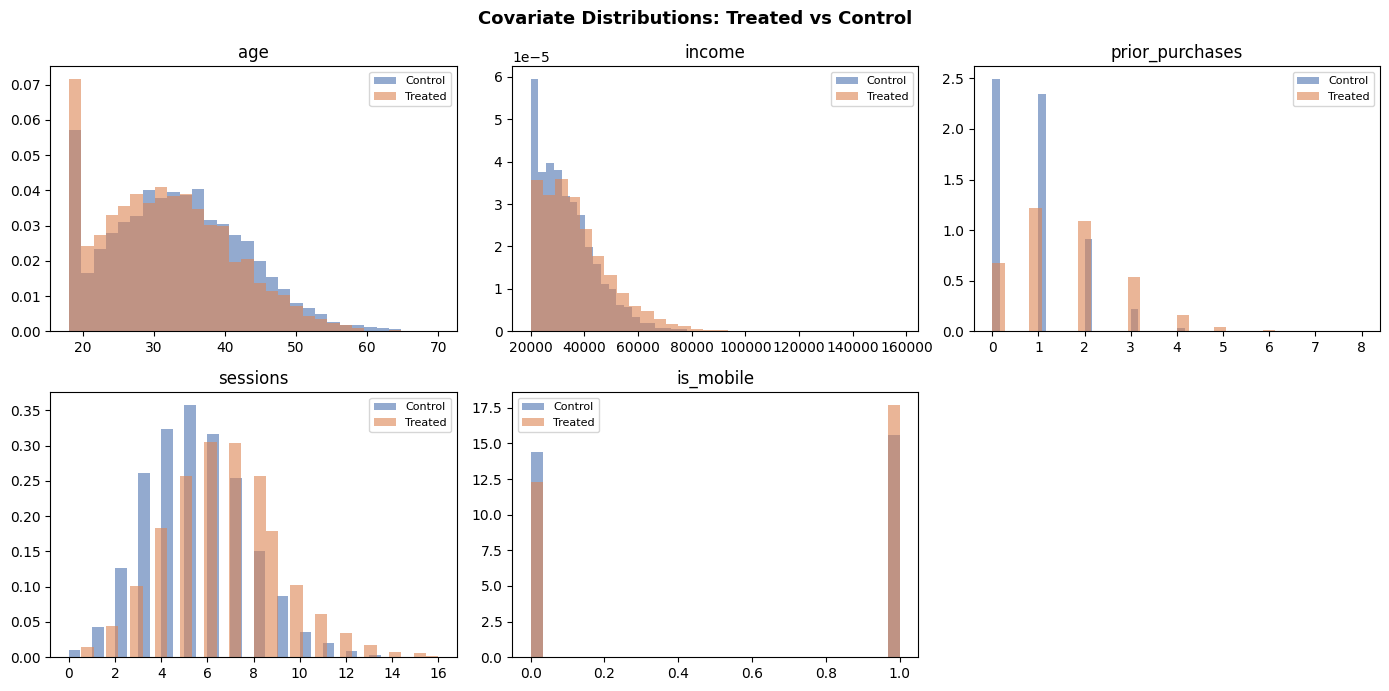


--- Mean Covariate Values by Treatment ---


,age,income,prior_purchases,sessions,is_mobile
T,,,,,
0,33.137,33534.181,0.827,5.291,0.519
1,31.524,36965.636,1.596,6.714,0.590


In [4]:
covariates = ["age", "income", "prior_purchases", "sessions", "is_mobile"]
treated = df_post[df_post["T"] == 1]
control = df_post[df_post["T"] == 0]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(covariates):
    ax = axes[i]
    ax.hist(control[col], bins=30, alpha=0.6, label="Control", color="#4C72B0", density=True)
    ax.hist(treated[col], bins=30, alpha=0.6, label="Treated", color="#DD8452", density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle("Covariate Distributions: Treated vs Control", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n--- Mean Covariate Values by Treatment ---")
df_post.groupby("T")[covariates].mean().round(3)

## 4. Naive ATE — The Wrong Way
A simple difference in means between treated and control users.
Because high-intent users are more likely to receive discounts **and** more likely to purchase anyway, this estimate is upward-biased.

Naive ATE (biased):  0.2634
True ATE (ground truth): 0.0807
Bias: +0.1826


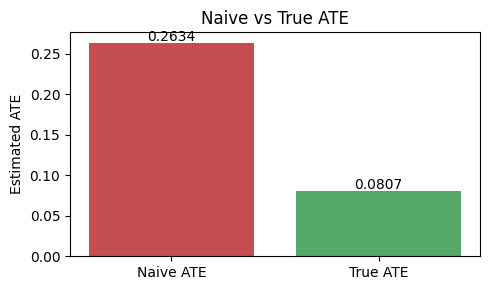

In [5]:
naive_ate = diff_in_means_ate(df_post, "Y", "T")
true_ate = meta["ate_true_post"]

print(f"Naive ATE (biased):  {naive_ate:.4f}")
print(f"True ATE (ground truth): {true_ate:.4f}")
print(f"Bias: {naive_ate - true_ate:+.4f}")

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(["Naive ATE", "True ATE"], [naive_ate, true_ate],
               color=["#C44E52", "#55A868"])
ax.set_ylabel("Estimated ATE")
ax.set_title("Naive vs True ATE")
for bar, val in zip(bars, [naive_ate, true_ate]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
            f"{val:.4f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 5. Pre vs Post Outcome Rates
We look at purchase rates in pre and post periods for treated and control groups.
The parallel trends assumption (required for DiD) says both groups should trend similarly in the pre-period.

      Control  Treated
Pre    0.1017   0.2610
Post   0.1182   0.3816


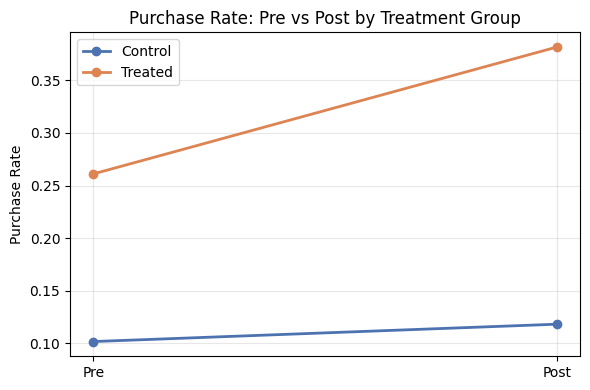

In [6]:
rates = df.groupby(["post", "T"])["Y"].mean().unstack()
rates.index = ["Pre", "Post"]
rates.columns = ["Control", "Treated"]
print(rates.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
for col, color in zip(["Control", "Treated"], ["#4C72B0", "#DD8452"]):
    ax.plot(["Pre", "Post"], rates[col], marker="o", label=col, color=color, linewidth=2)
ax.set_title("Purchase Rate: Pre vs Post by Treatment Group")
ax.set_ylabel("Purchase Rate")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Propensity Score Distribution
We estimate propensity scores (P(T=1|X)) and check for overlap between treated and control.
Good overlap means PSM matching will be valid. Poor overlap means extrapolation.

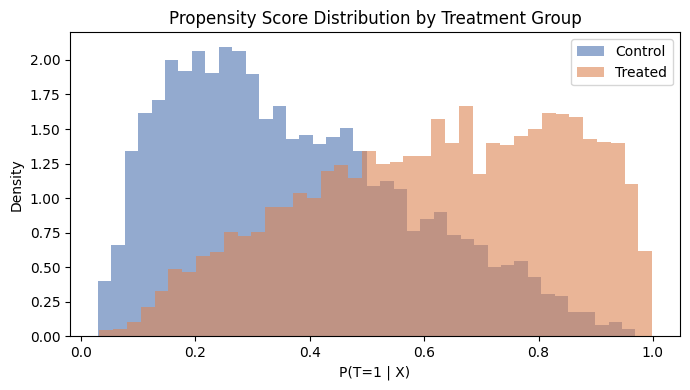

Treated pscore mean:  0.618
Control pscore mean:  0.370


In [7]:
pscore = estimate_propensity(df_post)
df_post = df_post.copy()
df_post["pscore"] = pscore

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_post[df_post["T"] == 0]["pscore"], bins=40, alpha=0.6,
        label="Control", color="#4C72B0", density=True)
ax.hist(df_post[df_post["T"] == 1]["pscore"], bins=40, alpha=0.6,
        label="Treated", color="#DD8452", density=True)
ax.set_title("Propensity Score Distribution by Treatment Group")
ax.set_xlabel("P(T=1 | X)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Treated pscore mean:  {df_post[df_post['T']==1]['pscore'].mean():.3f}")
print(f"Control pscore mean:  {df_post[df_post['T']==0]['pscore'].mean():.3f}")

## 7. Correlation Heatmap

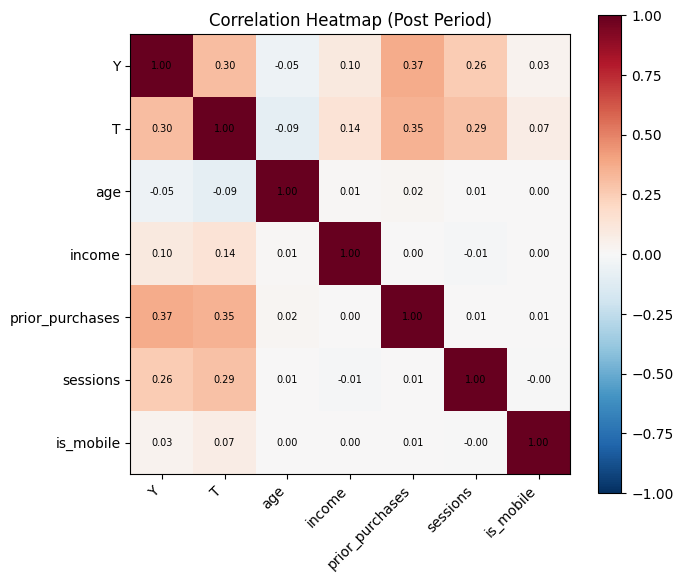

In [8]:
cols_for_corr = ["Y", "T", "age", "income", "prior_purchases", "sessions", "is_mobile"]
corr = df_post[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(cols_for_corr)))
ax.set_yticks(range(len(cols_for_corr)))
ax.set_xticklabels(cols_for_corr, rotation=45, ha="right")
ax.set_yticklabels(cols_for_corr)
for i in range(len(cols_for_corr)):
    for j in range(len(cols_for_corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Correlation Heatmap (Post Period)")
plt.tight_layout()
plt.show()

## Summary
Key takeaways from EDA:
- Treated users have higher `prior_purchases` and `sessions` — confirming confounding
- Naive ATE is upward-biased vs true ATE
- Propensity scores show reasonable overlap — PSM matching should be valid
- Pre/post trends look roughly parallel — DiD assumption approximately holds

➡️ Next: `02_causal_methods.ipynb` — apply DiD, PSM, and uplift modeling to recover the true ATE